# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
!pip install pandas
!pip install numpy
!pip install scikit-learn
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

Remove the first plot. As the amount of data used increases it shows a sharp decrease. So with more data you have a smaller loss of function. The second plot is more interesting with the number of estimators as the x-axis. It is showing that between 15-20 trees which helps chose the parameters. The number of estimators should be on the x-axis. 

In [3]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [4]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

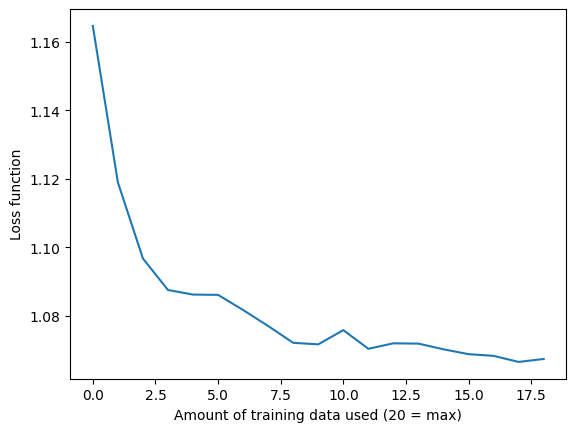

In [5]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [6]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

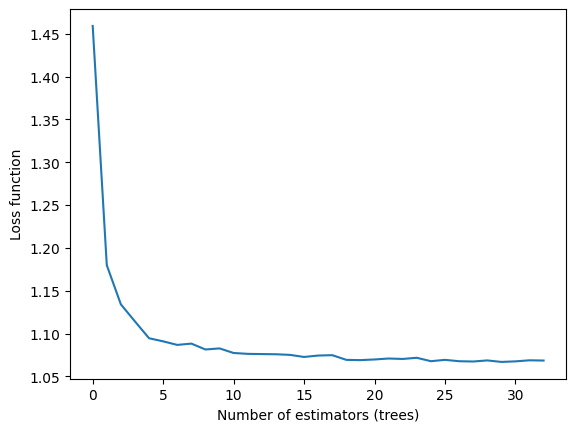

In [7]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [8]:
impair = pd.read_csv('drimpair.csv')
impair

,STATE,STATENAME,ST_CASE,VEH_NO,DRIMPAIR,DRIMPAIRNAME
0,1,Alabama,10001,1,2,Asleep or Fatigued
1,1,Alabama,10002,1,9,"Under the Influence of Alcohol, Drugs or Medic..."
2,1,Alabama,10003,1,99,Reported as Unknown if Impaired
3,1,Alabama,10004,1,9,"Under the Influence of Alcohol, Drugs or Medic..."
4,1,Alabama,10005,1,0,None/Apparently Normal
...,...,...,...,...,...,...
58479,56,Wyoming,560118,1,9,"Under the Influence of Alcohol, Drugs or Medic..."
58480,56,Wyoming,560119,1,0,None/Apparently Normal
58481,56,Wyoming,560120,1,0,None/Apparently Normal
58482,56,Wyoming,560120,2,0,None/Apparently Normal


In [9]:
accident = pd.read_csv('newaccident_23.csv')

In [10]:
person = pd.read_csv('person_23.csv')
person

,STATE,STATENAME,ST_CASE,MONTH,MONTHNAME,DAY,DAYNAME,HOUR,HOURNAME,RUR_URB,...,ATST_TYP,ATST_TYPNAME,ALC_RES,ALC_RESNAME,DRUGS,DRUGSNAME,DSTATUS,DSTATUSNAME,DOA,DOANAME
0,1,Alabama,10001,1,January,4,4,22,10:00pm-10:59pm,1,...,0,Test Not Given,996,Test Not Given,0,No (drugs not involved),0,Test Not Given,7,Died at Scene
1,1,Alabama,10002,3,March,20,20,2,2:00am-2:59am,1,...,1,Blood,217,0.217 % BAC,9,Reported as Unknown,2,Test Given,7,Died at Scene
2,1,Alabama,10003,3,March,18,18,22,10:00pm-10:59pm,1,...,1,Blood,148,0.148 % BAC,0,No (drugs not involved),2,Test Given,7,Died at Scene
3,1,Alabama,10004,3,March,17,17,19,7:00pm-7:59pm,1,...,1,Blood,117,0.117 % BAC,0,No (drugs not involved),2,Test Given,0,Not Applicable
4,1,Alabama,10004,3,March,17,17,19,7:00pm-7:59pm,1,...,0,Test Not Given,996,Test Not Given,8,Not Reported,0,Test Not Given,0,Not Applicable
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92395,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,0,Test Not Given,996,Test Not Given,8,Not Reported,0,Test Not Given,0,Not Applicable
92396,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,0,Test Not Given,996,Test Not Given,8,Not Reported,0,Test Not Given,0,Not Applicable
92397,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,0,Test Not Given,996,Test Not Given,8,Not Reported,0,Test Not Given,0,Not Applicable
92398,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,0,Test Not Given,996,Test Not Given,0,No (drugs not involved),0,Test Not Given,0,Not Applicable


In [11]:
df_merged = pd.merge(person, impair, on='ST_CASE', how='inner')

In [12]:
df_merged2 = pd.merge(df_merged, accident, on='ST_CASE', how='inner')
df_merged2 =df_merged2.loc[:, ~df_merged2.columns.str.endswith('_y')]
df_merged2.columns = df_merged2.columns.str.replace('_x', '', regex=False)
df_merged2

,STATE,STATENAME,ST_CASE,MONTH,MONTHNAME,DAY,DAYNAME,HOUR,HOURNAME,RUR_URB,...,WEATHER,WEATHERNAME,NOT_HOUR,NOT_HOURNAME,NOT_MIN,NOT_MINNAME,ARR_HOUR,ARR_HOURNAME,ARR_MIN,FATALS
0,1,Alabama,10001,1,January,4,4,22,10:00pm-10:59pm,1,...,1,Clear,22,10:00pm-10:59pm,20,20,22,10:00pm-10:59pm,45,1
1,1,Alabama,10002,3,March,20,20,2,2:00am-2:59am,1,...,1,Clear,2,2:00am-2:59am,8,8,2,2:00am-2:59am,23,1
2,1,Alabama,10003,3,March,18,18,22,10:00pm-10:59pm,1,...,1,Clear,22,10:00pm-10:59pm,48,48,23,11:00pm-11:59pm,8,1
3,1,Alabama,10004,3,March,17,17,19,7:00pm-7:59pm,1,...,2,Rain,19,7:00pm-7:59pm,0,0,19,7:00pm-7:59pm,44,1
4,1,Alabama,10004,3,March,17,17,19,7:00pm-7:59pm,1,...,2,Rain,19,7:00pm-7:59pm,0,0,19,7:00pm-7:59pm,44,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174866,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,1,Clear,8,8:00am-8:59am,43,43,9,9:00am-9:59am,1,1
174867,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,1,Clear,8,8:00am-8:59am,43,43,9,9:00am-9:59am,1,1
174868,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,1,Clear,8,8:00am-8:59am,43,43,9,9:00am-9:59am,1,1
174869,56,Wyoming,560120,12,December,29,29,8,8:00am-8:59am,1,...,1,Clear,8,8:00am-8:59am,43,43,9,9:00am-9:59am,1,1


In [13]:
df_merged2['AGE'].value_counts()

AGE
21     3933
20     3857
22     3811
19     3632
23     3618
       ... 
102       5
103       5
98        3
99        3
119       2
Name: count, Length: 107, dtype: int64

# Random Forest

In [14]:
df_merged2['RUR_URB'].value_counts()

RUR_URB
2    105181
1     68753
8       551
6       350
9        36
Name: count, dtype: int64

2 = urban  
1 = rural

In [15]:
df_merged2['SEX'].value_counts()

SEX
1    114083
2     57795
9      1623
8      1370
Name: count, dtype: int64

8 and 9 are either not reported or reported as unknown.   
1 = male
2 = female

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

Get sample size due to size of df, its crashing the kernel

In [18]:
df = df_merged2.sample(n=30000, random_state=42)

In [19]:
X = df[['WEATHERNAME', 'AGE', 'SEX', 'MONTH', 'DAY', 'RUR_URB', 'HOUR']]
y = df['DRIMPAIR']

In [20]:
X = X.dropna()
y = y.loc[X.index]

In [22]:
X = pd.get_dummies(X, columns=['WEATHERNAME','SEX','RUR_URB'], drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    max_depth=None)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [24]:
y_pred = rf.predict(X_test)

In [25]:
import matplotlib.pyplot as plt

#importances = rf.feature_importances_
#features = X.columns

#plt.figure()
#plt.barh(features, importances)
#plt.title("Features vs impaired driving")
#plt.show()

Day, month, and age are strong indicators for fatal accidents caused by impairment

# Cross Validation

In [26]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

scores = cross_val_score(rf, X, y, cv=3)
scores

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


array([0.468 , 0.4793, 0.4654])

46-48% accurate when I added hour into the validation.  

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

In [29]:
storytelling = pd.DataFrame({"Category":['Product A', 'Product B', 'Product C', 'Product D', 'Product E'],
                             "2008": [400, 360, 0, 0, 0],
                             "2009": [415, 400, 0, 0, 0],
                             "2010": [420, 410, 100, 0, 0],
                             "2011": [390, 380, 180, 150 , 0],
                             "2012": [300, 290, 200, 255, 0,],
                             "2013": [280, 250, 240, 215, 100],
                             "2014": [250, 240, 180, 210, 210]
                             })

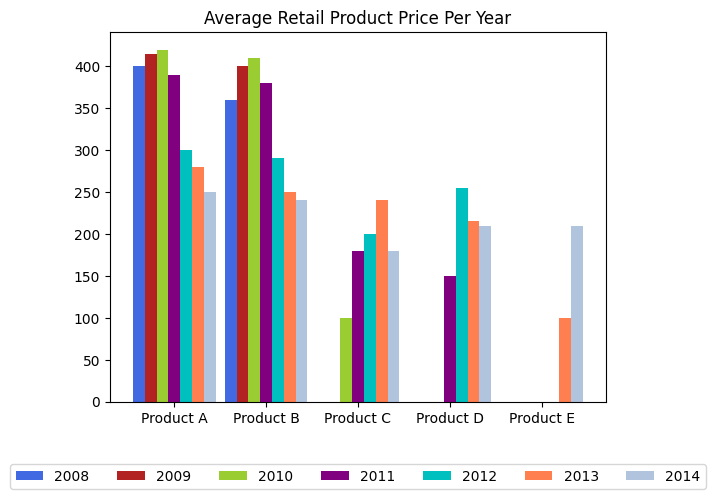

In [41]:
storytelling.set_index("Category").plot(kind="bar", title="Average Retail Product Price Per Year", color=["royalblue", "firebrick", "yellowgreen","purple", "c", "coral", "lightsteelblue" 
 ], width=0.9)
plt.xlabel("")

plt.xticks(rotation=0)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=len(storytelling.columns)
)

plt.show()